
Feature DF shape: (90, 16) Subjects: 35
  Subject      Class  tonic_variance  phasic_variance  phasic_mean_risetime  phasic_mean_recoverytime  max_scr_interval  scr_interval_rmssd  scr_peaks_per_min  scr_burst_fraction  peak_amplitude  \
0     F01    AEROBIC           24.97             0.03                  1.14                      0.72            634.00               60.67               5.03                0.47            1.30   
1     F01  ANAEROBIC           24.62             0.02                  0.93                      0.75            158.50               15.94               8.87                0.46            1.23   
2     F01     STRESS            0.09             0.00                  1.06                      0.77            387.75               67.31               3.08                0.33            0.47   
3     F02    AEROBIC            0.94             0.02                  1.41                      1.04            467.00               42.54               4.27         

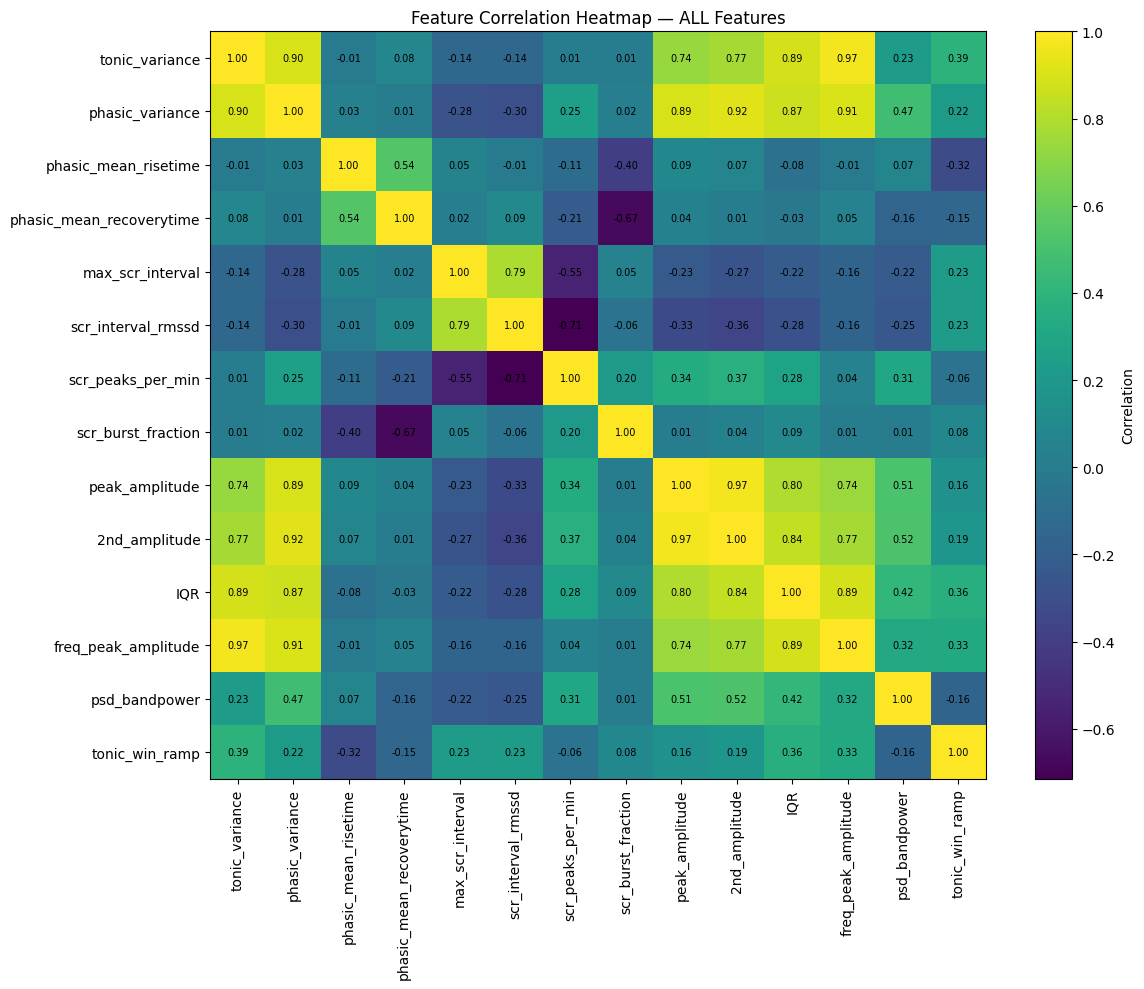


RFE selected features:
['tonic_variance', 'phasic_variance', 'phasic_mean_risetime', 'max_scr_interval', 'scr_interval_rmssd', 'scr_peaks_per_min', 'scr_burst_fraction', 'IQR', 'freq_peak_amplitude', 'tonic_win_ramp']

RFE ranking (1 = selected):
                 feature  ranking
          tonic_variance        1
         phasic_variance        1
    phasic_mean_risetime        1
        max_scr_interval        1
       scr_peaks_per_min        1
      scr_interval_rmssd        1
      scr_burst_fraction        1
     freq_peak_amplitude        1
          tonic_win_ramp        1
                     IQR        1
           psd_bandpower        2
          peak_amplitude        3
           2nd_amplitude        4
phasic_mean_recoverytime        5


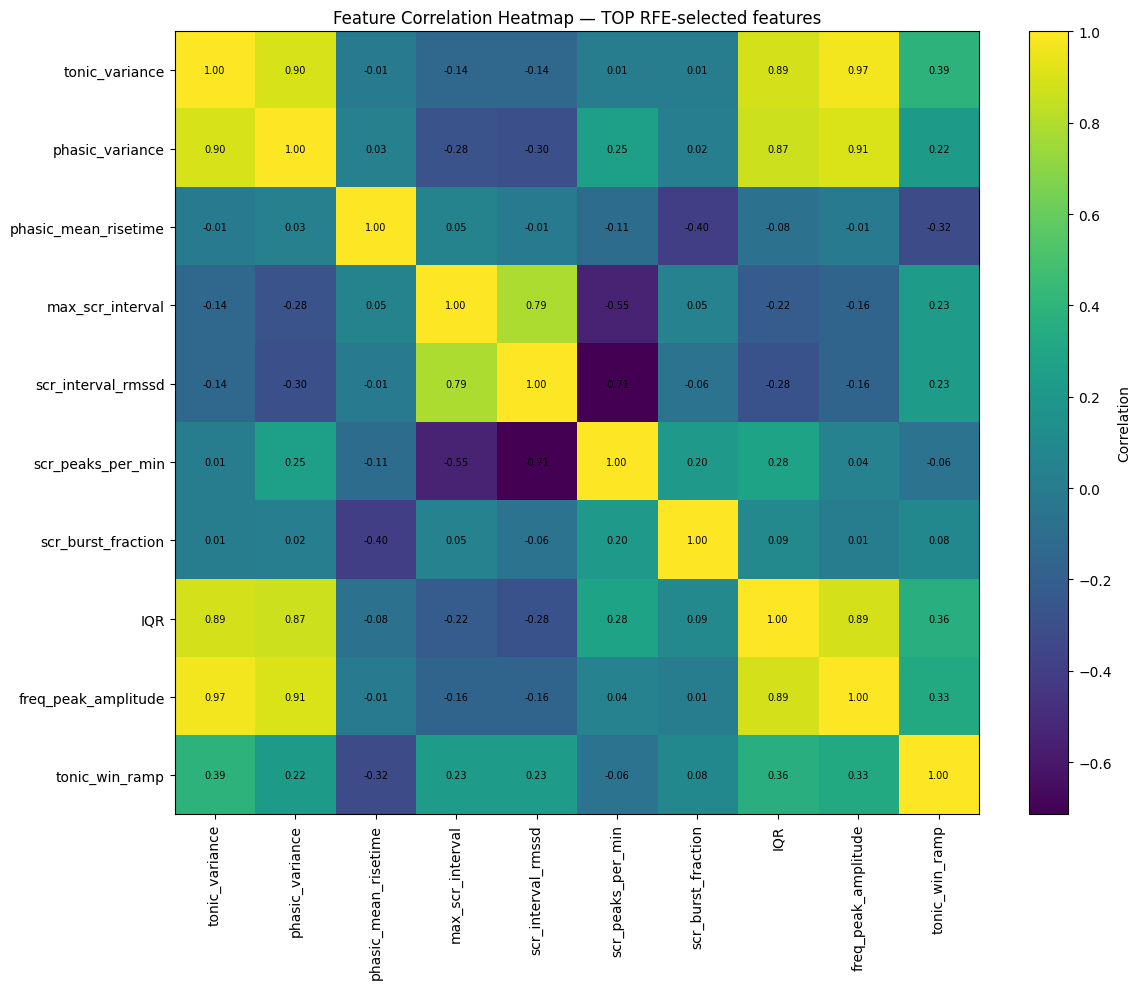

Low-correlation feature count: 8
Dropped due to |r| ≥ 0.75: ['phasic_variance', 'scr_interval_rmssd', 'peak_amplitude', '2nd_amplitude', 'IQR', 'freq_peak_amplitude']


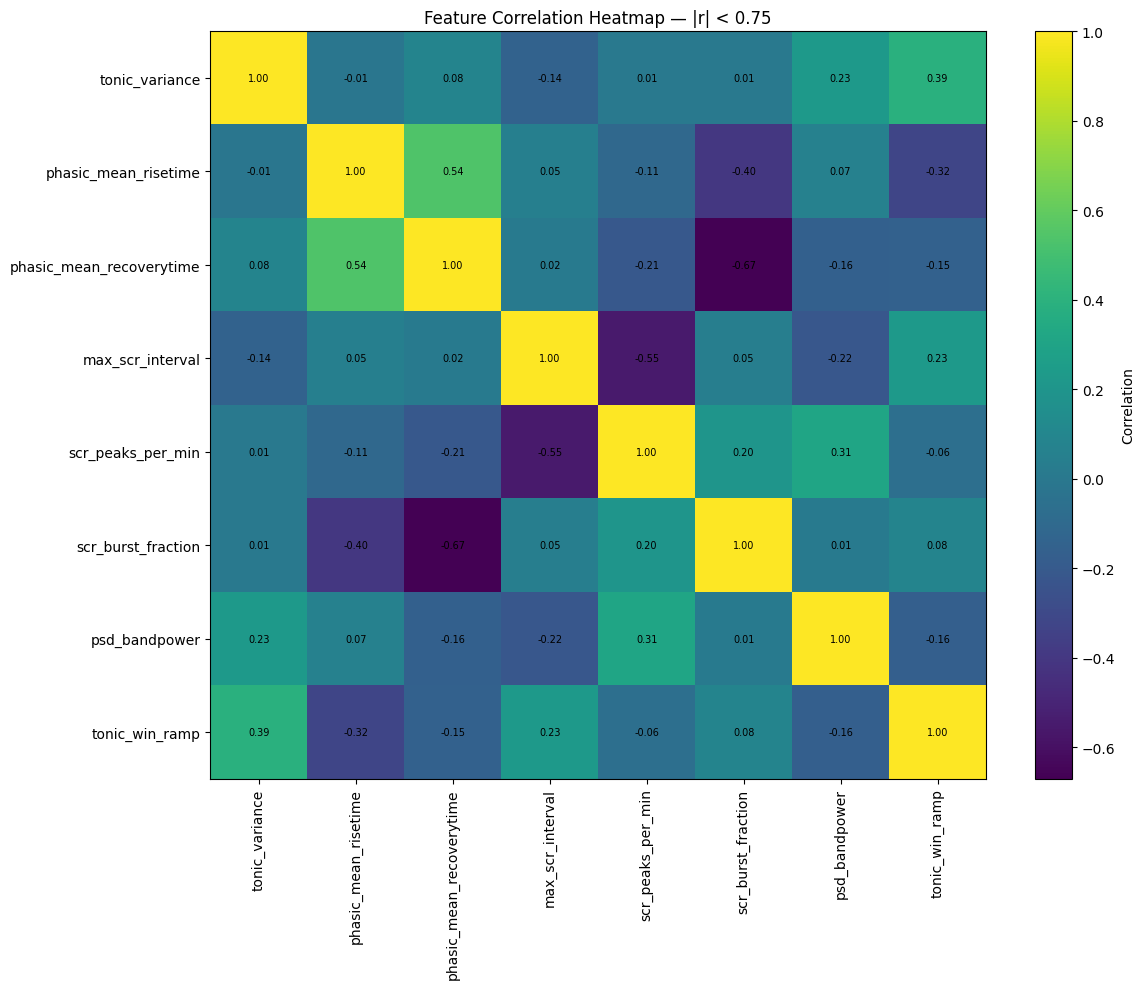


LOSO Results (RFE-selected features):
         Model  Accuracy_Mean  Accuracy_SD  Precision_Mean  Precision_SD  Recall_Mean  Recall_SD  FNR_Mean  FNR_SD  F1_Mean  F1_SD  N  Folds  Features
           LDA           0.70         0.32            0.61          0.37         0.70       0.32      0.27    0.28     0.64   0.36 90     35        10
           QDA           0.68         0.33            0.59          0.36         0.67       0.33      0.30    0.29     0.62   0.35 90     35        10
    ExtraTrees           0.67         0.32            0.57          0.37         0.66       0.32      0.30    0.30     0.60   0.35 90     35        10
  RandomForest           0.67         0.30            0.57          0.35         0.67       0.30      0.30    0.27     0.60   0.33 90     35        10
       XGBoost           0.65         0.32            0.55          0.36         0.65       0.32      0.32    0.30     0.58   0.35 90     35        10
           kNN           0.66         0.32            0

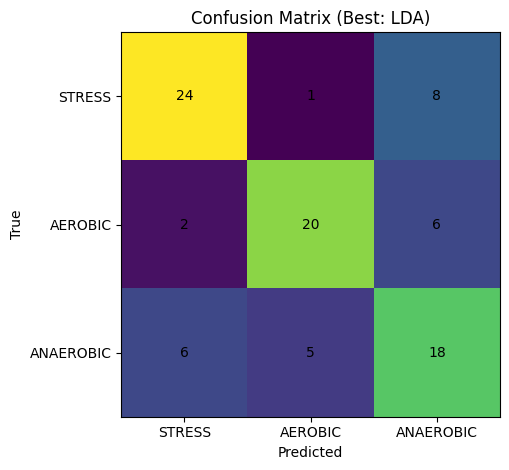


LOSO Results (low-correlation |r| < 0.75):
         Model  Accuracy_Mean  Accuracy_SD  Precision_Mean  Precision_SD  Recall_Mean  Recall_SD  FNR_Mean  FNR_SD  F1_Mean  F1_SD  N  Folds  Features
     GradBoost           0.70         0.28            0.59          0.35         0.70       0.28      0.27    0.24     0.62   0.33 90     35         8
    ExtraTrees           0.68         0.31            0.58          0.36         0.68       0.31      0.29    0.28     0.61   0.34 90     35         8
       XGBoost           0.68         0.28            0.57          0.34         0.68       0.28      0.30    0.25     0.61   0.32 90     35         8
LDA_autoshrink           0.65         0.33            0.56          0.38         0.65       0.33      0.30    0.27     0.59   0.36 90     35         8
           QDA           0.66         0.30            0.55          0.35         0.66       0.30      0.31    0.28     0.59   0.33 90     35         8
  RandomForest           0.65         0.31        

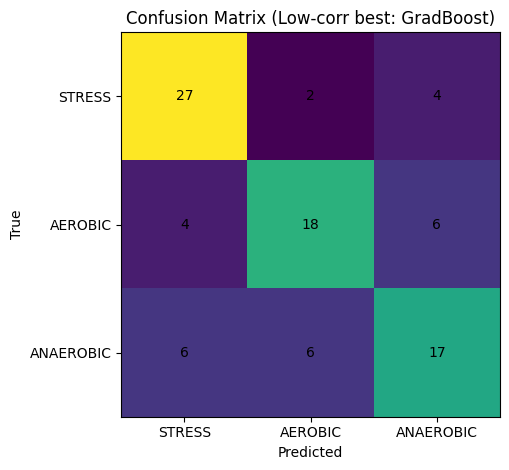

In [2]:
#!/usr/bin/env python3
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from biosppy import storage
from scipy.signal import butter, filtfilt, welch, find_peaks
from scipy.stats import kurtosis, skew, iqr

from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier

import warnings
warnings.filterwarnings("ignore", category=Warning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="nperseg*")

# Optional: LightGBM / XGBoost
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# -----------------------------#
#  Define hypoglycemia risk mapping
# ----1 = RISK, 0 = NON-RISK---#
risk_map = {
    0: 1,  # STRESS
    1: 0,  # AEROBIC
    2: 1,  # ANAEROBIC
}
# -----------------------------
# Signal processing helpers
# -----------------------------
def _filtfilt_safe(b, a, x):
    x = np.asarray(x, dtype=float).squeeze()
    padlen = 3 * (max(len(a), len(b)) - 1)
    if len(x) <= padlen:
        raise ValueError(f"Segment too short for filtfilt: len={len(x)} <= padlen={padlen}")
    return filtfilt(b, a, x)

def minmax_scale(x, eps=1e-8):
    x = np.asarray(x, dtype=float).squeeze()
    if x.size == 0:
        return x
    return (x - np.min(x)) / (np.max(x) - np.min(x) + eps)

def zscore_scale(x, eps=1e-8):
    """
    Z-score normalize a 1D signal: (x - mean) / std
    Safer than per-segment min-max because it preserves relative shape
    without forcing a fixed [0,1] range.
    """
    x = np.asarray(x, dtype=float).squeeze()
    if x.size == 0:
        return x
    mu = float(np.mean(x))
    sd = float(np.std(x))
    return (x - mu) / (sd + eps)

def butter_bandpass(x, fs, low=0.15, high=1, order=4): #consider low = 0.15, high = 0.4 to distinguish stress and exercise #initial was low=0.01 and high=0.4 
    nyq = 0.5 * fs
    if not (0 < low < high < nyq):
        raise ValueError(f"Bad bandpass cutoffs: low={low}, high={high}, nyq={nyq}")
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return _filtfilt_safe(b, a, x)

def butter_lowpass(x, fs, cutoff=0.05, order=4):
    nyq = 0.5 * fs
    if not (0 < cutoff < nyq):
        raise ValueError(f"Bad lowpass cutoff: cutoff={cutoff}, nyq={nyq}")
    b, a = butter(order, cutoff/nyq, btype="low")
    return _filtfilt_safe(b, a, x)

def butter_highpass(x, fs, cutoff=0.05, order=4):
    nyq = 0.5 * fs
    if not (0 < cutoff < nyq):
        raise ValueError(f"Bad highpass cutoff: cutoff={cutoff}, nyq={nyq}")
    b, a = butter(order, cutoff/nyq, btype="high")
    return _filtfilt_safe(b, a, x)

def bandpower(freqs, psd, fmin, fmax):
    mask = (freqs >= fmin) & (freqs <= fmax)
    if np.sum(mask) < 2:
        return 0.0
    return float(np.trapezoid(psd[mask], freqs[mask]))

# -----------------------------
# Feature extraction
# -----------------------------
def extract_features(x, fs):
    x = np.asarray(x, dtype=float).squeeze()
    eps = 1e-8
    if len(x) < 20:
        raise ValueError(f"Segment too short for features: len={len(x)}")

    tonic = butter_lowpass(x, fs, 0.05)
    phasic = butter_bandpass(x, fs, low=0.1, high=1, order=4)

    prom = np.std(phasic) if np.std(phasic) > 0 else 1e-8
    peaks, _ = find_peaks(phasic, prominence=prom)
    peak_amps = phasic[peaks] if len(peaks) else np.array([0.0])
    # -------------------------------
    # NEW: mean peak amplitude normalized by tonic mean
    # -------------------------------
    peak_amp_mean = float(np.mean(peak_amps)) if len(peak_amps) else 0.0
    tonic_global_mean = float(np.mean(tonic))
    peak_amp_mean_over_tonic_mean = float(peak_amp_mean / (tonic_global_mean + 1e-8))

    rise_times, recovery_times = [], []
    for p in peaks:
        # ---------- BASELINE ----------
        lb = max(0, p - int(10 * fs))
        baseline = np.median(phasic[lb:p]) if p > lb else phasic[p]

        peak_val = phasic[p]
        amp = peak_val - baseline
        if amp <= 1e-8:
            continue

        # ---------- RISE TIME (onset → peak) ----------
        onset_thresh = baseline + 0.05 * amp
        i = p
        while i > lb and phasic[i] > onset_thresh:
            i -= 1
        rise_times.append((p - i) / fs)

        # ---------- RECOVERY TIME (peak → 50% decay) ----------
        rec_thresh = baseline + 0.5 * amp
        ra = min(len(phasic) - 1, p + int(15 * fs))
        j = p
        while j < ra and phasic[j] > rec_thresh:
            j += 1
        recovery_times.append((j - p) / fs)

    scr_interval = np.diff(peaks) / fs if len(peaks) >= 2 else np.array([0.0])
    scr_interval_rmssd = float(np.sqrt(np.mean(np.diff(scr_interval) ** 2))) if len(scr_interval) > 2 else 0.0

    # NEW: burstiness = fraction of short inter-peak intervals (clustered SCRs)
    burst_thresh_sec = 4.0  # good starting point at fs=4Hz; tune 3–6s if needed
    scr_burst_fraction = float(np.mean(scr_interval < burst_thresh_sec)) if len(scr_interval) else 0.0

    duration_sec = len(x) / fs
    peak_density = float(len(peaks) / (duration_sec + eps))
    scr_peaks_per_min = float(len(peaks) / ((duration_sec / 60) + eps))

    # -------------------------------
    # NEW: phasic RMS variability over time (windowed)
    # -------------------------------
    win_sec_rms = 120
    step_sec_rms = 30
    win = int(win_sec_rms * fs)
    step = int(step_sec_rms * fs)

    phasic_rms_windows = []
    if len(phasic) >= win and win > 0 and step > 0:
        for i in range(0, len(phasic) - win + 1, step):
            w = phasic[i:i+win]
            phasic_rms_windows.append(float(np.sqrt(np.mean(w ** 2))))

    phasic_rms_windows = np.asarray(phasic_rms_windows, dtype=float)

    if len(phasic_rms_windows) > 1:
        phasic_rms_std_over_time = float(np.std(phasic_rms_windows))
        phasic_rms_cv = float(np.std(phasic_rms_windows) / (np.mean(phasic_rms_windows) + 1e-8))
    else:
        phasic_rms_std_over_time = 0.0
        phasic_rms_cv = 0.0

    nperseg = min(2048, len(x))
    freqs, psd = welch(x, fs=fs, window="hann", nperseg=nperseg, scaling="density")

    psd_peaks, _ = find_peaks(psd)
    psd_peak_amps = psd[psd_peaks] if len(psd_peaks) else np.array([0.0])

    def second_largest(arr):
        arr = np.asarray(arr, dtype=float)
        if len(arr) < 2:
            return 0.0
        return float(np.partition(arr, -2)[-2])

    return {
        #"mean_tonic_eda": float(np.mean(tonic)),
        #"mean_phasic_eda": float(np.mean(phasic)),
        "tonic_variance": float(np.var(tonic)),
        "phasic_variance": float(np.var(phasic)),
        "phasic_mean_risetime": float(np.mean(rise_times)) if len(rise_times) else 0.0,
        "phasic_mean_recoverytime": float(np.mean(recovery_times)) if len(recovery_times) else 0.0,
        "max_scr_interval": float(np.max(scr_interval)),
        "scr_interval_rmssd": float(np.sqrt(np.mean(np.diff(scr_interval) ** 2))) if len(scr_interval) > 2 else 0.0,
        "scr_peaks_per_min": scr_peaks_per_min,
        "scr_burst_fraction": scr_burst_fraction,  # NEW
        #"kurtosis": float(kurtosis(x)),
        #"skewness": float(skew(x)),
        "peak_amplitude": float(np.max(peak_amps)),
        #"peak_amplitude_mean": float(np.mean(peak_amps)) if len(peak_amps) else 0.0,   
        "2nd_amplitude": second_largest(peak_amps),
        "IQR": float(iqr(x)),
        "freq_peak_amplitude": float(np.max(psd_peak_amps)) if len(psd_peak_amps) else 0.0,
        "psd_bandpower": bandpower(freqs, psd, 0.01, 1.0), 
        # "phasic_rms_std_over_time": phasic_rms_std_over_time,
        # "phasic_rms_cv": phasic_rms_cv,
        # "peak_amp_mean_over_tonic_mean": peak_amp_mean_over_tonic_mean,
    }

# -----------------------------
# Tonic sequence (trend) features
# -----------------------------
def sliding_windows(x, fs, win_sec=60, step_sec=15):
    x = np.asarray(x, dtype=float).squeeze()
    win = int(win_sec * fs)
    step = int(step_sec * fs)
    if len(x) < win or win <= 0 or step <= 0:
        return []
    return [x[i:i+win] for i in range(0, len(x) - win + 1, step)]

def safe_slope(y):
    y = np.asarray(y, dtype=float)
    if len(y) < 2 or np.allclose(np.std(y), 0):
        return 0.0
    t = np.arange(len(y), dtype=float)
    return float(np.cov(t, y, ddof=0)[0, 1] / (np.var(t) + 1e-12))

# def extract_tonic_sequence_features(x, fs, win_sec=30, step_sec=5):
#     x = np.asarray(x, dtype=float).squeeze()
#     tonic = butter_lowpass(x, fs=fs, cutoff=0.05)

#     wins = sliding_windows(tonic, fs, win_sec=win_sec, step_sec=step_sec)
#     if len(wins) == 0:
#         return {
#             "tonic_ratio_up": 0.0,
#             "tonic_mean_slope": 0.0,
#             "tonic_mean_late_minus_early": 0.0,
#             "activation_duration": 0.0,
#         }

#     tonic_means = np.array([np.mean(w) for w in wins], dtype=float)
#     tonic_means = np.nan_to_num(tonic_means, nan=0.0, posinf=0.0, neginf=0.0)

#     baseline = float(np.median(tonic_means))
#     tonic_ratio_up = float(np.mean(tonic_means > baseline))
#     tonic_mean_slope = safe_slope(tonic_means)

#     q = max(1, len(tonic_means) // 4)
#     early_mean = float(np.mean(tonic_means[:q]))
#     late_mean  = float(np.mean(tonic_means[-q:]))

#     above = tonic_means > baseline
#     max_run = run = 0
#     for v in above:
#         if v:
#             run += 1
#             max_run = max(max_run, run)
#         else:
#             run = 0
#     activation_duration = float(max_run * step_sec)

#     return {#tonic_mean_late_minus_early: #encodes early vs late segment timing
#             # activation_duration: reflects sustained tonic elevation tied to task phase
#             # tonic_ratio_up: can leak class information depending on baseline definition
#             # These features artificially inflate LOSO accuracy and were excluded to prevent temporal leakage and preserve physiological validity.
#             "tonic_ratio_up": tonic_ratio_up,
#             "tonic_mean_slope": tonic_mean_slope,
#             "activation_duration": activation_duration
#     }

#Simple tonic sequence features (small + explainable):
def extract_tonic_sequence_features(x, fs, win_sec=120, step_sec=30):
    x = np.asarray(x, dtype=float).squeeze()
    tonic = butter_lowpass(x, fs=fs, cutoff=0.05)

    # Windowed tonic trajectory
    wins = sliding_windows(tonic, fs, win_sec=win_sec, step_sec=step_sec)
    if len(wins) < 2:
        return {"tonic_win_ramp": 0.0}

    w_mean = np.array([np.mean(w) for w in wins], dtype=float)
    w_mean = np.nan_to_num(w_mean, nan=0.0, posinf=0.0, neginf=0.0)

    # Consecutive differences between window means
    d = np.diff(w_mean)
    if d.size == 0:
        return {"tonic_win_ramp": 0.0}

    # Longest run of *positive* increases
    max_run = 0
    run = 0
    for di in d:
        if di > 0:
            run += 1
            max_run = max(max_run, run)
        else:
            run = 0

    tonic_win_ramp = float(max_run * step_sec)

    return {
        "tonic_win_ramp": tonic_win_ramp
    }
# -----------------------------
# Build DF (now: iterate 3 class folders)
# -----------------------------
def build_feature_df(base_path):
    classes = ["STRESS", "AEROBIC", "ANAEROBIC"]
    rows, skipped = [], []

    for cls in classes:
        folder = os.path.join(base_path, cls)
        if not os.path.isdir(folder):
            skipped.append((cls, f"Missing folder: {folder}"))
            continue

        files = sorted(glob.glob(os.path.join(folder, "*.txt")))
        for fp in files:
            subject = os.path.splitext(os.path.basename(fp))[0]
            try:
                signal, meta = storage.load_txt(fp)
                fs = 4.0
                if isinstance(meta, dict):
                    fs = float(meta.get("sampling_rate", meta.get("sr", fs)))

                signal = np.asarray(signal, dtype=float).squeeze()
                if len(signal) == 0:
                    raise ValueError("Empty signal")

                # Processing with Z-score normalization and Butterworth bandpass filter
                signal_filt = butter_bandpass(signal, fs=fs, low=0.01, high=1.0, order=4)
                #signal_filt = minmax_scale(signal_filt)
                signal_filt_zscore = zscore_scale(signal_filt)

                
                #Extract Features and Tonic Sequence Features
                feats = extract_features(signal, fs) #use original signal for features - phasic/tonic separation and filtration internally in extract features
                seq   = extract_tonic_sequence_features(signal, fs, win_sec=120, step_sec=30)
                
                rows.append({"Subject": subject, "Class": cls, **feats, **seq})

            except Exception as e:
                skipped.append((f"{cls}/{subject}", str(e)))

    df = pd.DataFrame(rows)
    if df.empty:
        # Give a useful error message instead of KeyError
        print("\nNo rows were generated. All files were skipped.")
        print("First 15 skipped reasons:")
        for item in skipped[:15]:
            print("  ", item)
        return df, skipped

    df = df.sort_values(["Subject", "Class"]).reset_index(drop=True)
    return df, skipped

# -----------------------------
# Plot heatmap
# -----------------------------
def plot_corr_heatmap(corr, title="Feature Correlation Heatmap", annotate=True):
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(corr.values, aspect="auto")
    ax.set_title(title)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticklabels(corr.index)
    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(j, i, f"{corr.values[i, j]:.2f}",
                    ha="center", va="center", fontsize=7)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Correlation")
    plt.tight_layout()
    plt.show()

# -----------------------------
# LOSO eval (UPDATED: macro metrics + 3x3 confusion)
# -----------------------------
def loso_eval(models, X, y, groups, selected_features=None):
    loso = LeaveOneGroupOut()
    results = []
    confs = {}

    labels = [0, 1, 2]

    def macro_fnr(y_true, y_pred, labels):
        """
        Multiclass macro-FNR computed from confusion matrix:
        For each class c: FNR_c = FN_c / (FN_c + TP_c)
        Then macro-average across classes.
        """
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        fnrs = []
        for i in range(len(labels)):
            tp = cm[i, i]
            fn = cm[i, :].sum() - tp
            denom = tp + fn
            fnrs.append((fn / denom) if denom > 0 else 0.0)
        return float(np.mean(fnrs))

    for name, model in models.items():
        acc, bacc, prec, rec, f1, fnr = [], [], [], [], [], []
        y_true_all, y_pred_all = [], []

        for train_idx, test_idx in loso.split(X, y, groups=groups):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            y_true_all.extend(y_test.tolist())
            y_pred_all.extend(y_pred.tolist())

            acc.append(accuracy_score(y_test, y_pred))
            bacc.append(balanced_accuracy_score(y_test, y_pred))
            prec.append(precision_score(y_test, y_pred, average="macro", zero_division=0))
            rec.append(recall_score(y_test, y_pred, average="macro", zero_division=0))
            f1.append(f1_score(y_test, y_pred, average="macro", zero_division=0))

            # NEW: FNR per fold (3-class macro-FNR)
            fnr.append(macro_fnr(y_test, y_pred, labels))

        confs[name] = confusion_matrix(y_true_all, y_pred_all, labels=labels)

        results.append({
            "Model": name,
            "Accuracy_Mean": float(np.mean(acc)),
            "Accuracy_SD":   float(np.std(acc, ddof=1)) if len(acc) > 1 else 0.0,

            "Precision_Mean": float(np.mean(prec)),
            "Precision_SD":   float(np.std(prec, ddof=1)) if len(prec) > 1 else 0.0,

            "Recall_Mean": float(np.mean(rec)),
            "Recall_SD":   float(np.std(rec, ddof=1)) if len(rec) > 1 else 0.0,

            "FNR_Mean": float(np.mean(fnr)),
            "FNR_SD":   float(np.std(fnr, ddof=1)) if len(fnr) > 1 else 0.0,

            "F1_Mean": float(np.mean(f1)),
            "F1_SD":   float(np.std(f1, ddof=1)) if len(f1) > 1 else 0.0,

            "N": int(len(y_true_all)),
            "Folds": int(len(acc)),
            "Features": int(selected_features if selected_features is not None else X.shape[1])
        })

    return pd.DataFrame(results).sort_values("Precision_Mean", ascending=False), confs

# -----------------------------
# STRATIFIED 5-FOLD (UPDATED: macro metrics + 3x3 confusion)
# -----------------------------
def stratified_5fold_eval(models, X, y, selected_features=None, seed=42):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    rows = []
    confs = {}

    labels = [0, 1, 2] #STRESS=0, AEROBIC=1, ANAEROBIC=2

    def macro_fnr(y_true, y_pred, labels):
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        fnrs = []
        for i in range(len(labels)):
            tp = cm[i, i]
            fn = cm[i, :].sum() - tp
            denom = tp + fn
            fnrs.append((fn / denom) if denom > 0 else 0.0)
        return float(np.mean(fnrs))

    for name, model in models.items():
        accs, baccs, precs, recs, f1s, fnrs = [], [], [], [], [], []
        y_true_all, y_pred_all = [], []

        for train_idx, test_idx in skf.split(X, y):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            y_true_all.extend(y_test.tolist())
            y_pred_all.extend(y_pred.tolist())

            accs.append(accuracy_score(y_test, y_pred))
            baccs.append(balanced_accuracy_score(y_test, y_pred))
            precs.append(precision_score(y_test, y_pred, average="macro", zero_division=0))
            recs.append(recall_score(y_test, y_pred, average="macro", zero_division=0))
            f1s.append(f1_score(y_test, y_pred, average="macro", zero_division=0))

            # NEW: FNR per fold
            fnrs.append(macro_fnr(y_test, y_pred, labels))

        confs[name] = confusion_matrix(y_true_all, y_pred_all, labels=labels)

        rows.append({
            "Model": name,
            "Accuracy_Mean": float(np.mean(accs)),
            "Accuracy_SD":   float(np.std(accs, ddof=1)) if len(accs) > 1 else 0.0,

            # "BalancedAcc_Mean": float(np.mean(baccs)),
            # "BalancedAcc_SD":   float(np.std(baccs, ddof=1)) if len(baccs) > 1 else 0.0,

            # "Precision_Mean": float(np.mean(precs)),
            # "Precision_SD":   float(np.std(precs, ddof=1)) if len(precs) > 1 else 0.0,

            "Recall_Mean": float(np.mean(recs)),
            "Recall_SD":   float(np.std(recs, ddof=1)) if len(recs) > 1 else 0.0,

            "FNR_Mean": float(np.mean(fnrs)),
            "FNR_SD":   float(np.std(fnrs, ddof=1)) if len(fnrs) > 1 else 0.0,

            # "F1_Mean": float(np.mean(f1s)),
            # "F1_SD":   float(np.std(f1s, ddof=1)) if len(f1s) > 1 else 0.0,

            "Folds": 5,
            "Features": int(selected_features if selected_features is not None else X.shape[1])
        })

    df = pd.DataFrame(rows).sort_values("Accuracy_Mean", ascending=False)
    return df, confs

def stratified_10fold_eval(models, X, y, selected_features=None, seed=42):
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)
    rows = []
    confs = {}

    labels = [0, 1, 2]

    def macro_fnr(y_true, y_pred, labels):
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        fnrs = []
        for i in range(len(labels)):
            tp = cm[i, i]
            fn = cm[i, :].sum() - tp
            denom = tp + fn
            fnrs.append((fn / denom) if denom > 0 else 0.0)
        return float(np.mean(fnrs))

    for name, model in models.items():
        accs, recs, fnrs = [], [], []
        y_true_all, y_pred_all = [], []

        for train_idx, test_idx in skf.split(X, y):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            y_true_all.extend(y_test.tolist())
            y_pred_all.extend(y_pred.tolist())

            accs.append(accuracy_score(y_test, y_pred))
            recs.append(recall_score(y_test, y_pred, average="macro", zero_division=0))
            fnrs.append(macro_fnr(y_test, y_pred, labels))

        confs[name] = confusion_matrix(y_true_all, y_pred_all, labels=labels)

        rows.append({
            "Model": name,
            "Accuracy_Mean": np.mean(accs),
            "Accuracy_SD":   np.std(accs, ddof=1),
            "Recall_Mean":   np.mean(recs),
            "Recall_SD":     np.std(recs, ddof=1),
            "FNR_Mean":      np.mean(fnrs),
            "FNR_SD":        np.std(fnrs, ddof=1),
            "Folds": 10,
            "Features": int(selected_features if selected_features is not None else X.shape[1]),
        })

    return pd.DataFrame(rows).sort_values("Accuracy_Mean", ascending=False), confs

# -----------------------------
# MAIN
# -----------------------------
def main():
    base_path = r"C:\Users\Ramya Sankar\Downloads\EDA_Files\Wearable_Dataset"
    feature_df, skipped = build_feature_df(base_path)

    if skipped:
        print("\nSkipped items:")
        for sid, reason in skipped:
            print(f"  {sid}: {reason}")

    print("\nFeature DF shape:", feature_df.shape, "Subjects:", feature_df["Subject"].nunique())
    print(feature_df.head())
    # ============================================================
    # FULL FEATURE TABLE (all features, 3 rows per subject)
    # ============================================================
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 200)

    print("\nFULL FEATURE TABLE (sorted by Class, then Subject):")
    print(
        feature_df
        .sort_values(["Class", "Subject"])
        .to_string(index=False)
    )

    # ----- 3-class label encoding -----
    class_order = ["STRESS", "AEROBIC", "ANAEROBIC"]
    class_to_int = {c: i for i, c in enumerate(class_order)}
    int_to_class = {i: c for c, i in class_to_int.items()}

    y = feature_df["Class"].map(class_to_int).astype(int).values
    groups = feature_df["Subject"].values

    # ALL feature columns
    feature_cols = [c for c in feature_df.columns if c not in ["Subject", "Class"]]
    X_df = feature_df[feature_cols].copy()
    X = X_df.values

    # Heatmap (ALL features)
    corr_all = X_df.corr()
    plot_corr_heatmap(corr_all, title="Feature Correlation Heatmap — ALL Features", annotate=True)

    # RFE top K (unchanged)
    k = 10 #min(20, max(12, X_df.shape[1] // 4)) #k = 12
    rfe_est = LogisticRegression(max_iter=5000, solver="lbfgs")
    
    rfe_pipeline = Pipeline(steps=[
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("rfe", RFE(estimator=rfe_est, n_features_to_select=k))
    ])# KEEP EXACT behavior: Pipeline

    rfe_pipeline.fit(X, y)
    support = rfe_pipeline.named_steps["rfe"].support_
    selected = [f for f, keep in zip(feature_cols, support) if keep]

    ranking = rfe_pipeline.named_steps["rfe"].ranking_
    ranking_df = pd.DataFrame({"feature": feature_cols, "ranking": ranking}).sort_values("ranking")

    print("\nRFE selected features:")
    print(selected)
    print("\nRFE ranking (1 = selected):")
    print(ranking_df.to_string(index=False))

    # Heatmap (TOP RFE features)
    corr_top = X_df[selected].corr()
    plot_corr_heatmap(corr_top, title="Feature Correlation Heatmap — TOP RFE-selected features", annotate=True)

    # -----------------------------
    # Heatmap: features with |r| < 0.8 (redundancy check) (unchanged)
    # -----------------------------
    corr_abs = X_df.corr().abs()
    upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] >= 0.75)] #drop features that have more than 75% correlation with any other feature
    low_corr_features = [c for c in X_df.columns if c not in to_drop]

    print(f"Low-correlation feature count: {len(low_corr_features)}")
    print("Dropped due to |r| ≥ 0.75:", to_drop)

    corr_low = X_df[low_corr_features].corr()
    plot_corr_heatmap(corr_low, title="Feature Correlation Heatmap — |r| < 0.75", annotate=True)

    # Use ONLY selected features for modeling
    X_sel = X_df[selected].values

    models = {
        "LRC3": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            #("log", FunctionTransformer(safe_log1p, validate=False)),
            ("scaler", RobustScaler()),
            ("clf", LogisticRegression(C=3,max_iter=3000, class_weight="balanced", solver="lbfgs")) #consider "liblinear" as well for small datasets # check different C (regularization parameter for Log Reg) for C in [0.1, 0.3, 1.0, 3.0]:
        ]),
        "LDA": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
            ("clf", LinearDiscriminantAnalysis(priors=[1/3, 1/3, 1/3])) # STRESS, AEROBIC, ANAEROBIC
        ]),
        "LDA_autoshrink": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", RobustScaler()),
            ("clf", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"))
        ]),
        "GNB": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("clf", GaussianNB(var_smoothing=1e-8)) #also try var_smoothing IN [1e-9, 1e-8, 1e-7, 1e-6] to prevent near-zero variance features from dominating the likelihood calculations #reduce numerical instability in LOSO
        ]), 
        "SVM-RBF": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", RobustScaler()),
            ("clf", SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced"))
        ]),
        "RandomForest": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(n_estimators=300, random_state=42))
        ]),
        "GradBoost": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("clf", GradientBoostingClassifier(random_state=42))
        ]),
        "kNN": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("clf", KNeighborsClassifier(n_neighbors=7, weights="distance", metric="minkowski", p=2)),
        ]),
        "DecisionTree": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("clf", DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, class_weight="balanced", random_state=42))
        ]),
        "ExtraTrees": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("clf", ExtraTreesClassifier(n_estimators=400, random_state=42, n_jobs=-1))
        ]),
        "MLP": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("clf", MLPClassifier(hidden_layer_sizes=(32, 16), activation="relu",
                                  solver="adam", alpha=1e-3, max_iter=2000, random_state=42))
        ]),
        "QDA": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("clf", QuadraticDiscriminantAnalysis(reg_param=0.1))
        ]),
    }

    if LGBMClassifier is not None:
        models["LightGBM"] = Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("clf", LGBMClassifier(
                n_estimators=500, learning_rate=0.05, num_leaves=31,
                subsample=0.9, colsample_bytree=0.9, random_state=42, verbose=-1))
        ])

    if XGBClassifier is not None:
        models["XGBoost"] = Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("clf", XGBClassifier(
                n_estimators=500, learning_rate=0.05, max_depth=4,
                subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
                random_state=42, eval_metric="logloss"))
        ])

    # ---------- LOSO with RFE-selected features ----------
    results_sel, confs_sel = loso_eval(models, X_sel, y, groups, selected_features=len(selected))

    pd.set_option("display.float_format", "{:.2f}".format)
    print("\nLOSO Results (RFE-selected features):")
    print(results_sel.to_string(index=False))

    # --------- Stratified 5-fold with RFE-selected features ----------
    results_5fold, confs_5fold = stratified_5fold_eval(models, X_sel, y, selected_features=len(selected), seed=42)
    print("\nStratified 5-fold Results (RFE-selected features):")
    print(results_5fold.to_string(index=False))
   
    # ---------- Dataset-protocol benchmark: Stratified 10-fold ----------
    results_10fold, confs_10fold = stratified_10fold_eval(models, X_sel, y, selected_features=len(selected),seed=42)
    print("\nStratified 10-fold Results (dataset benchmark):")
    print(results_10fold.to_string(index=False))
    
    best_model_name = results_sel.iloc[0]["Model"]
    cm = confs_sel[best_model_name]

    class_labels = class_order

    fig, ax = plt.subplots(figsize=(5.2, 4.8))
    im = ax.imshow(cm, aspect="auto")
    ax.set_title(f"Confusion Matrix (Best: {best_model_name})")
    ax.set_xticks([0, 1, 2]); ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(class_labels)
    ax.set_yticklabels(class_labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.show()

    # ---------- LOSO with low-correlation features ----------
    X_low_df = X_df[low_corr_features].copy()
    X_low = X_low_df.values

    results_low, confs_low = loso_eval(models, X_low, y, groups, selected_features=len(low_corr_features))
    print("\nLOSO Results (low-correlation |r| < 0.75):")
    print(results_low.to_string(index=False))

    best_low_name = results_low.iloc[0]["Model"]
    cm_low = confs_low[best_low_name]

    fig, ax = plt.subplots(figsize=(5.2, 4.8))
    im = ax.imshow(cm_low, aspect="auto")
    ax.set_title(f"Confusion Matrix (Low-corr best: {best_low_name})")
    ax.set_xticks([0, 1, 2]); ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(class_labels)
    ax.set_yticklabels(class_labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(cm_low[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()